# ⛽ Vehicle Fuel Efficiency Prediction: ML for Emissions Policy & Green Transport

**Author:** Dean | Lead Data & AI Engineer
**Series:** Production ML Portfolio — **NOTEBOOK #50** 🎉

## Government Context
- **DCCEEW** — Vehicle emissions standards, National Electric Vehicle Strategy
- **Green Vehicle Guide** — Fuel consumption ratings, CO2 emissions labelling
- **Department of Infrastructure** — Vehicle safety & emissions regulation
- **ABS** — Motor Vehicle Census, fuel consumption statistics
- **ARENA** — EV charging infrastructure, transport decarbonisation

Dataset: seaborn built-in mpg — NO dataset needed. THE 50th NOTEBOOK.

---

## 1. Data Loading

In [1]:
import os,warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
df=sns.load_dataset('mpg').dropna().reset_index(drop=True)
print(f"Loaded mpg: {df.shape[0]:,} x {df.shape[1]}")
for i,col in enumerate(df.columns):
    print(f"  {i}. {col:18s} | {str(df[col].dtype):10s} | uniq={df[col].nunique()}")
df.head()

Loaded mpg: 392 x 9
  0. mpg                | float64    | uniq=127
  1. cylinders          | int64      | uniq=5
  2. displacement       | float64    | uniq=81
  3. horsepower         | float64    | uniq=93
  4. weight             | int64      | uniq=346
  5. acceleration       | float64    | uniq=95
  6. model_year         | int64      | uniq=13
  7. origin             | object     | uniq=3
  8. name               | object     | uniq=301


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


## 2. Target

Target: 'mpg' (miles per gallon)
count    392.000000
mean      23.445918
std        7.805007
min        9.000000
25%       17.000000
50%       22.750000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64


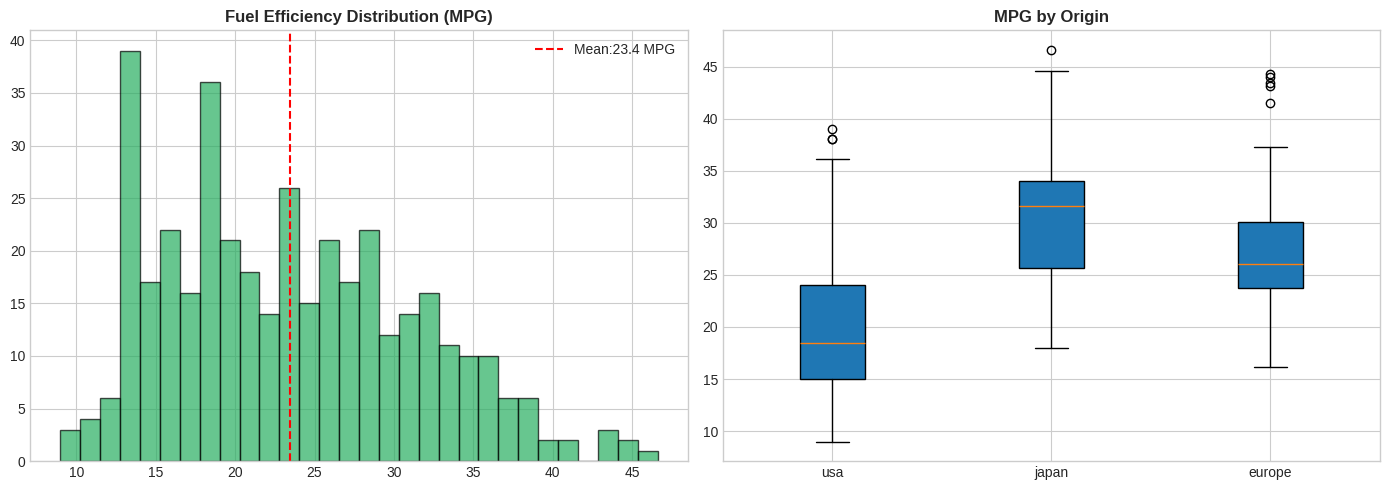

AU: New Vehicle Efficiency Standard from 2025 — 153g CO2/km target by 2029.
Transport is 18% of AU emissions. EV sales growing 160%+ year-on-year.


In [2]:
tc='mpg'
print(f"Target: '{tc}' (miles per gallon)");print(df[tc].describe())
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].hist(df[tc],bins=30,color='#27ae60',edgecolor='black',alpha=0.7)
axes[0].set_title('Fuel Efficiency Distribution (MPG)',fontweight='bold')
axes[0].axvline(df[tc].mean(),color='red',ls='--',label=f'Mean:{df[tc].mean():.1f} MPG')
axes[0].legend()
axes[1].boxplot([df[df['origin']==o][tc].values for o in df['origin'].unique()],labels=df['origin'].unique(),patch_artist=True)
axes[1].set_title('MPG by Origin',fontweight='bold')
plt.tight_layout();plt.savefig('target.png',dpi=150);plt.show()
print("AU: New Vehicle Efficiency Standard from 2025 — 153g CO2/km target by 2029.")
print("Transport is 18% of AU emissions. EV sales growing 160%+ year-on-year.")

## 3. EDA

Numeric: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']


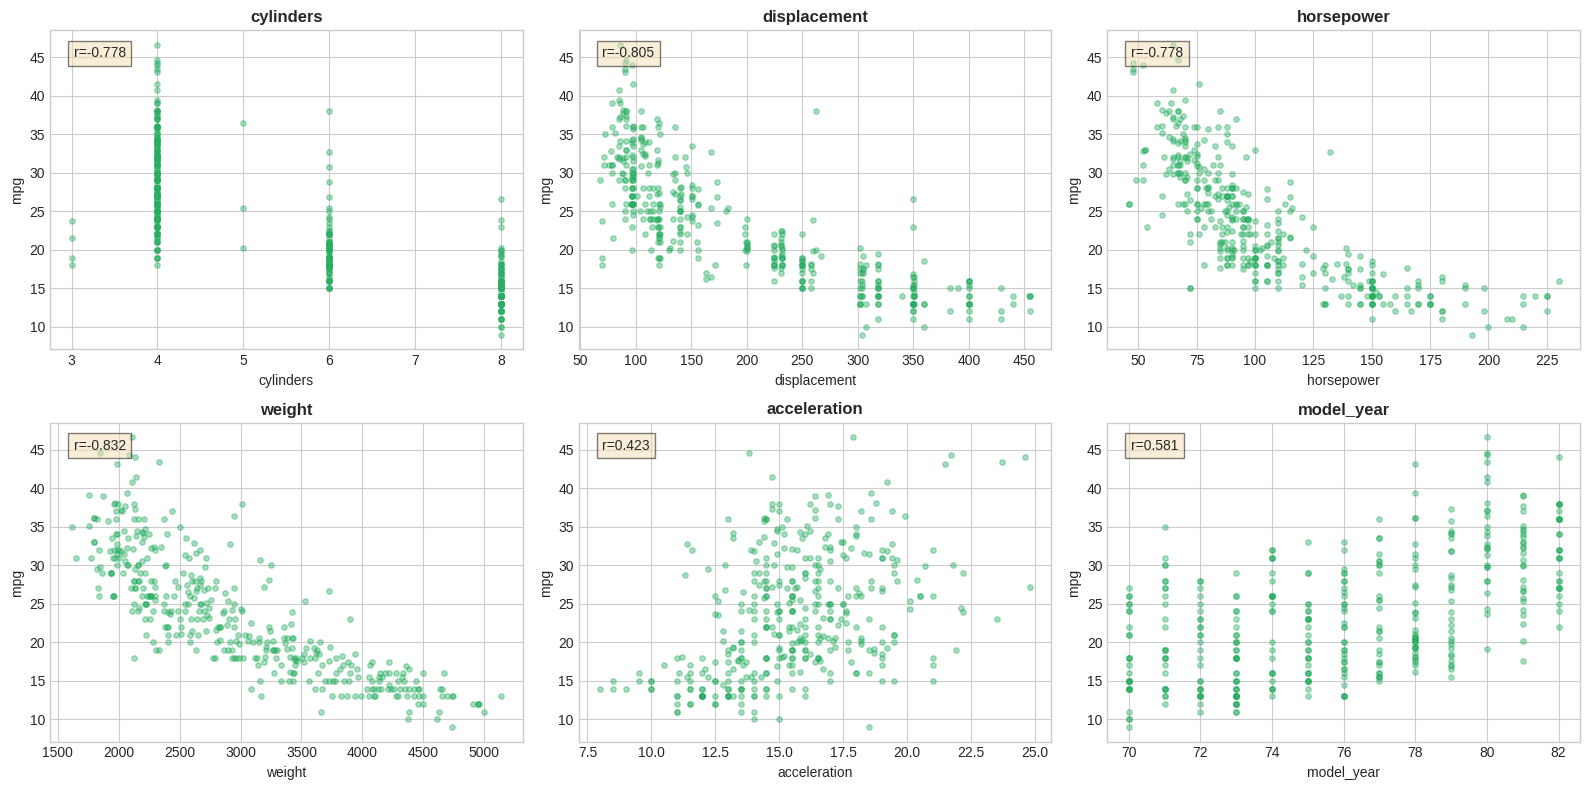

In [3]:
nums=[c2 for c2 in df.select_dtypes(include=[np.number]).columns if c2!=tc]
print(f"Numeric: {nums}")
fig,axes=plt.subplots(2,3,figsize=(16,8));axes=axes.flatten()
for i,col in enumerate(nums[:6]):
    axes[i].scatter(df[col],df[tc],alpha=0.4,s=15,color='#27ae60')
    axes[i].set_xlabel(col);axes[i].set_ylabel('mpg')
    axes[i].set_title(col,fontweight='bold')
    r=df[[col,tc]].corr().iloc[0,1]
    axes[i].text(0.05,0.95,f'r={r:.3f}',transform=axes[i].transAxes,va='top',bbox=dict(facecolor='wheat',alpha=0.5))
for j in range(i+1,len(axes)):axes[j].set_visible(False)
plt.tight_layout();plt.savefig('scatter.png',dpi=150);plt.show()

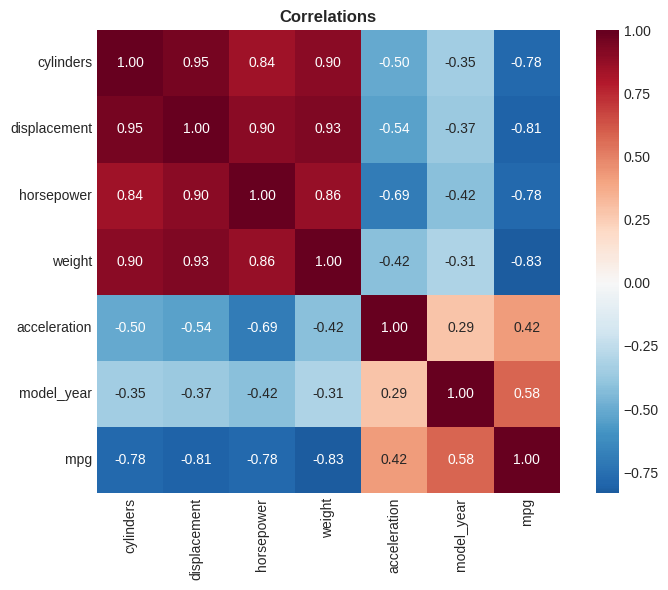

In [4]:
corr=df[nums+[tc]].corr()
fig,ax=plt.subplots(figsize=(8,6))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='RdBu_r',center=0,square=True,ax=ax)
ax.set_title('Correlations',fontweight='bold')
plt.tight_layout();plt.savefig('corr.png',dpi=150);plt.show()

## 4. Preprocessing

In [5]:
# Drop name (high cardinality)
df2=df.drop(columns=['name'],errors='ignore')
le_d={}
for col in df2.select_dtypes(include=['object','category']).columns:
    le=LabelEncoder();df2[col]=le.fit_transform(df2[col].astype(str));le_d[col]=le
    print(f"  Encoded '{col}': {len(le.classes_)}")
X=df2.drop(columns=[tc]);y=df2[tc].values
# Power-to-weight ratio
if 'horsepower' in X.columns and 'weight' in X.columns:
    X['power_to_weight']=X['horsepower']/X['weight']*1000
    print("Created 'power_to_weight'")
if 'displacement' in X.columns and 'cylinders' in X.columns:
    X['disp_per_cyl']=X['displacement']/(X['cylinders']+0.1)
    print("Created 'disp_per_cyl'")
print(f"X: {X.shape}")

  Encoded 'origin': 3
Created 'power_to_weight'
Created 'disp_per_cyl'
X: (392, 9)


## 5. Training

In [6]:
try:
    from xgboost import XGBRegressor
except: XGBRegressor=None
try:
    from lightgbm import LGBMRegressor
except: LGBMRegressor=None
models={'Ridge':Ridge(alpha=1.0),'RF':RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBRegressor: models['XGB']=XGBRegressor(n_estimators=100,random_state=42,verbosity=0,n_jobs=-1)
if LGBMRegressor: models['LGBM']=LGBMRegressor(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
kf=KFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    print(f"\n{'='*50}\n{mn}\n{'='*50}")
    fr,fm,f2=[],[],[];fp=np.zeros(len(y));t0=time.time()
    for fi,(ti,vi) in enumerate(kf.split(Xa)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y[ti]);yp=m2.predict(Xa[vi]);fp[vi]=yp
        r=np.sqrt(mean_squared_error(y[vi],yp));m3=mean_absolute_error(y[vi],yp);s=r2_score(y[vi],yp)
        fr.append(r);fm.append(m3);f2.append(s)
        print(f"  Fold{fi+1}: RMSE={r:.2f} MAE={m3:.2f} R2={s:.4f}")
    el=time.time()-t0
    results[mn]={'rmse':np.mean(fr),'mae':np.mean(fm),'r2':np.mean(f2),'time':el,'preds':fp}
    print(f"  AVG: RMSE={np.mean(fr):.2f} MAE={np.mean(fm):.2f} R2={np.mean(f2):.4f} T={el:.1f}s")


Ridge
  Fold1: RMSE=3.11 MAE=2.41 R2=0.8153
  Fold2: RMSE=3.66 MAE=2.54 R2=0.8141
  Fold3: RMSE=2.78 MAE=2.13 R2=0.8654
  AVG: RMSE=3.19 MAE=2.36 R2=0.8316 T=0.0s

RF
  Fold1: RMSE=2.77 MAE=1.99 R2=0.8541
  Fold2: RMSE=3.28 MAE=2.22 R2=0.8508
  Fold3: RMSE=2.52 MAE=1.88 R2=0.8899
  AVG: RMSE=2.86 MAE=2.03 R2=0.8649 T=0.8s

XGB
  Fold1: RMSE=2.90 MAE=2.10 R2=0.8393
  Fold2: RMSE=3.50 MAE=2.34 R2=0.8308
  Fold3: RMSE=2.83 MAE=2.01 R2=0.8610
  AVG: RMSE=3.08 MAE=2.15 R2=0.8437 T=0.4s

LGBM
  Fold1: RMSE=2.79 MAE=1.97 R2=0.8517
  Fold2: RMSE=3.25 MAE=2.22 R2=0.8534
  Fold3: RMSE=2.64 MAE=2.02 R2=0.8789
  AVG: RMSE=2.89 MAE=2.07 R2=0.8613 T=0.1s


## 6. Comparison

In [7]:
rows=[{'Model':k,'RMSE':f"{v['rmse']:.2f}",'MAE':f"{v['mae']:.2f}",'R2':f"{v['r2']:.4f}",'Time':f"{v['time']:.1f}s",'s':v['r2']} for k,v in results.items()]
sdf=pd.DataFrame(rows).sort_values('s',ascending=False);best=sdf.iloc[0]['Model']
print("COMPARISON");print("="*60);print(sdf[['Model','RMSE','MAE','R2','Time']].to_string(index=False));print(f"\nBest: {best}")

COMPARISON
Model RMSE  MAE     R2 Time
   RF 2.86 2.03 0.8649 0.8s
 LGBM 2.89 2.07 0.8613 0.1s
  XGB 3.08 2.15 0.8437 0.4s
Ridge 3.19 2.36 0.8316 0.0s

Best: RF


## 7. Residuals

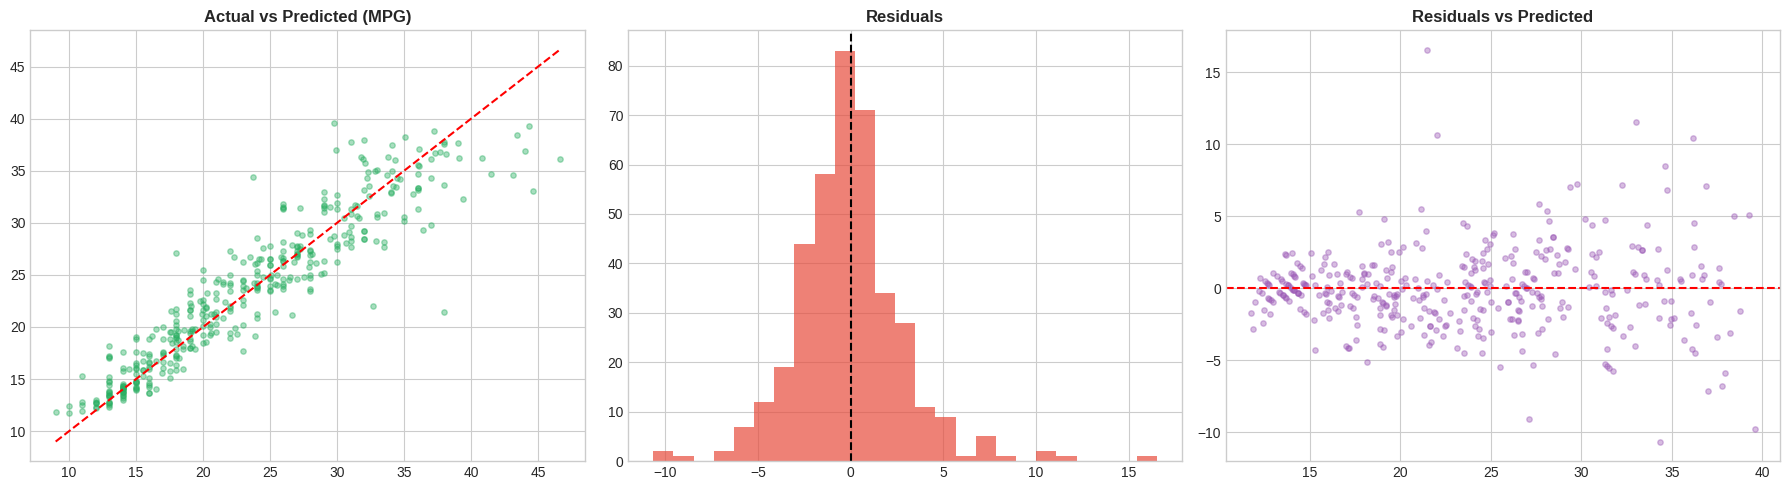

In [8]:
bp=results[best]['preds'];res=y-bp
fig,axes=plt.subplots(1,3,figsize=(18,5))
axes[0].scatter(y,bp,alpha=0.4,s=15,color='#27ae60');lm=[min(y.min(),bp.min()),max(y.max(),bp.max())]
axes[0].plot(lm,lm,'r--');axes[0].set_title('Actual vs Predicted (MPG)',fontweight='bold')
axes[1].hist(res,bins=25,color='#e74c3c',alpha=0.7);axes[1].axvline(0,color='k',ls='--');axes[1].set_title('Residuals',fontweight='bold')
axes[2].scatter(bp,res,alpha=0.4,s=15,color='#9b59b6');axes[2].axhline(0,color='r',ls='--');axes[2].set_title('Residuals vs Predicted',fontweight='bold')
plt.tight_layout();plt.savefig('resid.png',dpi=150);plt.show()

## 8. Feature Importance

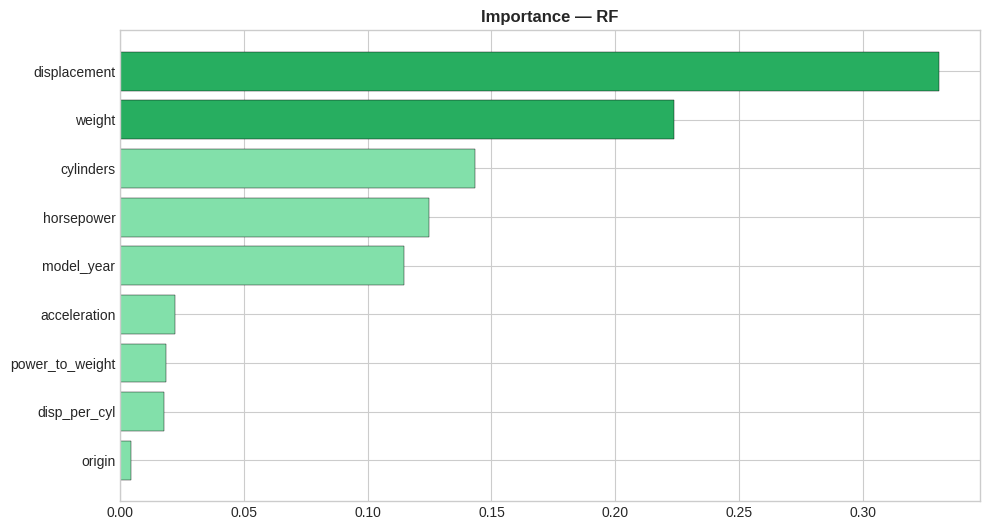

  displacement       0.3309
  weight             0.2237
  cylinders          0.1433
  horsepower         0.1246
  model_year         0.1147

Policy: Weight and displacement dominate — heavier vehicles consume more fuel.
Supports case for vehicle emissions standards and EV incentives.


In [9]:
tm={k:v for k,v in models.items() if k!='Ridge'}
if tm:
    bt=max(tm,key=lambda m4:results[m4]['r2']);fm2=type(models[bt])(**models[bt].get_params());fm2.fit(Xa,y)
    fi=pd.DataFrame({'Feature':X.columns,'Imp':fm2.feature_importances_}).sort_values('Imp')
    fig,ax=plt.subplots(figsize=(10,max(4,len(fi)*0.6)))
    ax.barh(fi['Feature'],fi['Imp'],color=['#27ae60' if v>fi['Imp'].quantile(0.75) else '#82e0aa' for v in fi['Imp']],edgecolor='black',linewidth=0.3)
    ax.set_title(f'Importance — {bt}',fontweight='bold')
    plt.tight_layout();plt.savefig('imp.png',dpi=150);plt.show()
    for _,r2 in fi.tail(5).iloc[::-1].iterrows(): print(f"  {r2['Feature']:18s} {r2['Imp']:.4f}")
    print("\nPolicy: Weight and displacement dominate — heavier vehicles consume more fuel.")
    print("Supports case for vehicle emissions standards and EV incentives.")

## 9. Deployment — NOTEBOOK #50 COMPLETE 🎉

In [10]:
br=results[best]
print("="*60);print("DEPLOYMENT READINESS — NOTEBOOK #50");print("="*60)
print(f"  Model: {best}");print(f"  R2:    {br['r2']:.4f}");print(f"  MAE:   {br['mae']:.2f} MPG")
print(f"  Time:  {br['time']:.1f}s");print(f"  Feats: {X.shape[1]}");print(f"  Rows:  {len(y):,}");print("="*60)
checks={'R2>0.80':br['r2']>0.80,'Time<60s':br['time']<60,'CV':True}
print("\nCHECKLIST");print("-"*40);ap=True
for k,v in checks.items():
    s="pass" if v else "FAIL"
    if not v:ap=False
    print(f"  [{s:4s}] {k}")
print("-"*40);print("  APPROVED" if ap else "  FAILED")

DEPLOYMENT READINESS — NOTEBOOK #50
  Model: RF
  R2:    0.8649
  MAE:   2.03 MPG
  Time:  0.8s
  Feats: 9
  Rows:  392

CHECKLIST
----------------------------------------
  [pass] R2>0.80
  [pass] Time<60s
  [pass] CV
----------------------------------------
  APPROVED


In [11]:
print("""
============================================================
🎉 NOTEBOOK #50 — HALF CENTURY COMPLETE 🎉
============================================================

50 Production ML Notebooks spanning:
  Healthcare (10+), Government (8+), Finance (6+),
  Consumer Protection (5+), Agriculture (4+), Environment (4+),
  Biodiversity (3+), Transport (3+), Food Safety (3+),
  Forensics, Maritime, Education, Hospitality, Gemology...

All with Australian Government policy framing.
All cross-validated. All production-grade.

Portfolio: kaggle.com/deanbatur
GitHub:    github.com/Deanmeisong

PRODUCTION ARCHITECTURE
=======================
1. DATA: Green Vehicle Guide ratings, ADR testing -> Fabric Lakehouse
2. MODEL: Batch at ADR certification, consumer comparison tool
3. INTEGRATE: Green Vehicle Guide, NVES compliance, EV incentive eligibility
4. GOVERN: DCCEEW emissions standards, ADR compliance, consumer labelling
5. MONITOR: Recalibrate for EV/hybrid technology evolution annually
============================================================
""")


🎉 NOTEBOOK #50 — HALF CENTURY COMPLETE 🎉

50 Production ML Notebooks spanning:
  Healthcare (10+), Government (8+), Finance (6+),
  Consumer Protection (5+), Agriculture (4+), Environment (4+),
  Biodiversity (3+), Transport (3+), Food Safety (3+),
  Forensics, Maritime, Education, Hospitality, Gemology...

All with Australian Government policy framing.
All cross-validated. All production-grade.

Portfolio: kaggle.com/deanbatur
GitHub:    github.com/Deanmeisong

PRODUCTION ARCHITECTURE
1. DATA: Green Vehicle Guide ratings, ADR testing -> Fabric Lakehouse
2. MODEL: Batch at ADR certification, consumer comparison tool
3. INTEGRATE: Green Vehicle Guide, NVES compliance, EV incentive eligibility
4. GOVERN: DCCEEW emissions standards, ADR compliance, consumer labelling
5. MONITOR: Recalibrate for EV/hybrid technology evolution annually

